
# Задание №3. Скрытые характеристики ЭЭГ во время приступа

**Цель:** исследование скрытых характеристик сигналов электроэнцефалографии.



## 0. Установка зависимостей



In [ ]:
# !pip install mne pyedflib pywavelets scipy matplotlib numpy pandas tqdm requests

## 1. Импорты

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sg
import pywt
import mne
import requests
from tqdm.auto import tqdm

mne.set_log_level("WARNING")  
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True


FIG_W = 14


c:\Users\Егор Букин\Desktop\Эргадические системы\lab3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## 2. Скачивание данных 



In [ ]:
DATA_DIR = "."
EEG_ID = 44                                
EEG_FILE = os.path.join(DATA_DIR, f"eeg{EEG_ID}.edf")
ANN_FILE = os.path.join(DATA_DIR, "annotations_2017_A.csv")

ZENODO = "https://zenodo.org/records/2547147/files"
URLS = {
    EEG_FILE: f"{ZENODO}/eeg{EEG_ID}.edf?download=1",
    ANN_FILE: f"{ZENODO}/annotations_2017_A.csv?download=1",
}

def download(url: str, path: str) -> None:
    if os.path.exists(path) and os.path.getsize(path) > 0:
        print(f"уже есть: {path} ({os.path.getsize(path)/1e6:.1f} MB)")
        return
    print(f"скачиваю {url} -> {path}")
    with requests.get(url, stream=True, timeout=300) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        with open(path, "wb") as f, tqdm(total=total, unit="B", unit_scale=True) as bar:
            for chunk in r.iter_content(chunk_size=1 << 15):
                if chunk:
                    f.write(chunk)
                    bar.update(len(chunk))

for path, url in URLS.items():
    download(url, path)


уже есть: .\eeg44.edf (36.1 MB)
уже есть: .\annotations_2017_A.csv (1.6 MB)



## 3. Поиск приступа



In [ ]:
ann = pd.read_csv(ANN_FILE)
print("форма таблицы аннотаций:", ann.shape)       
print("первые колонки:", list(ann.columns[:5]))

col = str(EEG_ID)
labels = ann[col].dropna().astype(int).to_numpy()  
print(f"\nдлительность аннотации для ребёнка #{EEG_ID}: {len(labels)} с "
      f"({len(labels)/60:.1f} мин)")
print(f"всего секунд приступа: {labels.sum()}")

def find_runs(mask: np.ndarray):
    runs = []
    i = 0
    while i < len(mask):
        if mask[i] == 1:
            j = i
            while j < len(mask) and mask[j] == 1:
                j += 1
            runs.append((i, j))   
            i = j
        else:
            i += 1
    return runs

seizures = find_runs(labels)
print(f"\nнайдено {len(seizures)} приступов:")
for k, (s, e) in enumerate(seizures, 1):
    print(f"  №{k}: {s} — {e} с  (длительность {e-s} с,  "
          f"{s//60} мин {s%60:02d} сек  →  {e//60} мин {e%60:02d} сек)")


форма таблицы аннотаций: (15416, 79)
первые колонки: ['1', '2', '3', '4', '5']

длительность аннотации для ребёнка #44: 3360 с (56.0 мин)
всего секунд приступа: 341

найдено 7 приступов:
  №1: 193 — 213 с  (длительность 20 с,  3 мин 13 сек  →  3 мин 33 сек)
  №2: 293 — 375 с  (длительность 82 с,  4 мин 53 сек  →  6 мин 15 сек)
  №3: 643 — 661 с  (длительность 18 с,  10 мин 43 сек  →  11 мин 01 сек)
  №4: 1058 — 1160 с  (длительность 102 с,  17 мин 38 сек  →  19 мин 20 сек)
  №5: 2503 — 2518 с  (длительность 15 с,  41 мин 43 сек  →  41 мин 58 сек)
  №6: 2969 — 2988 с  (длительность 19 с,  49 мин 29 сек  →  49 мин 48 сек)
  №7: 3023 — 3108 с  (длительность 85 с,  50 мин 23 сек  →  51 мин 48 сек)



## 4. Чтение EDF-файла




In [5]:
raw = mne.io.read_raw_edf(EEG_FILE, preload=True, verbose="ERROR")

print("частота дискретизации:", raw.info["sfreq"], "Гц")
print("длительность:", raw.times[-1], "с (", raw.times[-1]/60, "мин )")
print("число каналов:", len(raw.ch_names))
print("каналы:", raw.ch_names)


частота дискретизации: 256.0 Гц
длительность: 3359.99609375 с ( 55.999934895833334 мин )
число каналов: 21
каналы: ['EEG Fp1-REF', 'EEG Fp2-REF', 'EEG F3-REF', 'EEG F4-REF', 'EEG C3-REF', 'EEG C4-REF', 'EEG P3-REF', 'EEG P4-REF', 'EEG O1-REF', 'EEG O2-REF', 'EEG F7-REF', 'EEG F8-REF', 'EEG T3-REF', 'EEG T4-REF', 'EEG T5-REF', 'EEG T6-REF', 'EEG Fz-REF', 'EEG Cz-REF', 'EEG Pz-REF', 'ECG EKG-REF', 'Resp Effort-REF']


In [ ]:
EEG_NAMES_1020 = {"Fp1","Fp2","F3","F4","F7","F8","Fz","C3","C4","Cz",
                  "P3","P4","Pz","T3","T4","T5","T6","O1","O2",
                  "T7","T8","P7","P8"}

def is_eeg(name: str) -> bool:
    n = name.replace("EEG", "").replace("-Ref", "").replace("-REF", "").strip()
    n = n.split("-")[0].strip()
    return n in EEG_NAMES_1020

eeg_names = [c for c in raw.ch_names if is_eeg(c)]
print(f"оставлено ЭЭГ-каналов: {len(eeg_names)}")
print(eeg_names)

raw.pick(eeg_names)
fs = raw.info["sfreq"]
print("итоговая частота дискретизации:", fs, "Гц")


оставлено ЭЭГ-каналов: 19
['EEG Fp1-REF', 'EEG Fp2-REF', 'EEG F3-REF', 'EEG F4-REF', 'EEG C3-REF', 'EEG C4-REF', 'EEG P3-REF', 'EEG P4-REF', 'EEG O1-REF', 'EEG O2-REF', 'EEG F7-REF', 'EEG F8-REF', 'EEG T3-REF', 'EEG T4-REF', 'EEG T5-REF', 'EEG T6-REF', 'EEG Fz-REF', 'EEG Cz-REF', 'EEG Pz-REF']
итоговая частота дискретизации: 256.0 Гц



## 5. Вырезаем фрагмент в момент приступа

`SEIZURE_INDEX` — порядковый номер приступа из найденных.


In [ ]:
SEIZURE_INDEX = 3   
PRE_SEC  = 60      
POST_SEC = 60       

if seizures:
    idx = min(SEIZURE_INDEX, len(seizures) - 1)
    if idx != SEIZURE_INDEX:
        print(f"запрошенного приступа №{SEIZURE_INDEX+1} нет, беру №{idx+1}")
    s_sec, e_sec = seizures[idx]
    print(f"используем приступ №{idx+1}: {s_sec} — {e_sec} с "
          f"(длительность {e_sec-s_sec} с)")
    t_start = max(0, s_sec - PRE_SEC)
    t_end   = min(raw.times[-1], e_sec + POST_SEC)
else:
    print("приступов в этом файле не размечено — берём окно посередине записи")
    mid = raw.times[-1] / 2
    t_start, t_end = mid - 30, mid + 30
    s_sec, e_sec = None, None

print(f"вырезаем окно: {t_start:.1f} — {t_end:.1f} с "
      f"(длина {t_end-t_start:.1f} с)")

i0 = int(t_start * fs)
i1 = int(t_end   * fs)
data_uv = raw.get_data(start=i0, stop=i1) * 1e6 
t = np.arange(data_uv.shape[1]) / fs + t_start   
print("форма data_uv:", data_uv.shape, "  (n_channels, n_samples)")


используем приступ №4: 1058 — 1160 с (длительность 102 с)
вырезаем окно: 998.0 — 1220.0 с (длина 222.0 с)
форма data_uv: (19, 56832)   (n_channels, n_samples)



## 6. График ЭЭГ в момент приступа — все каналы


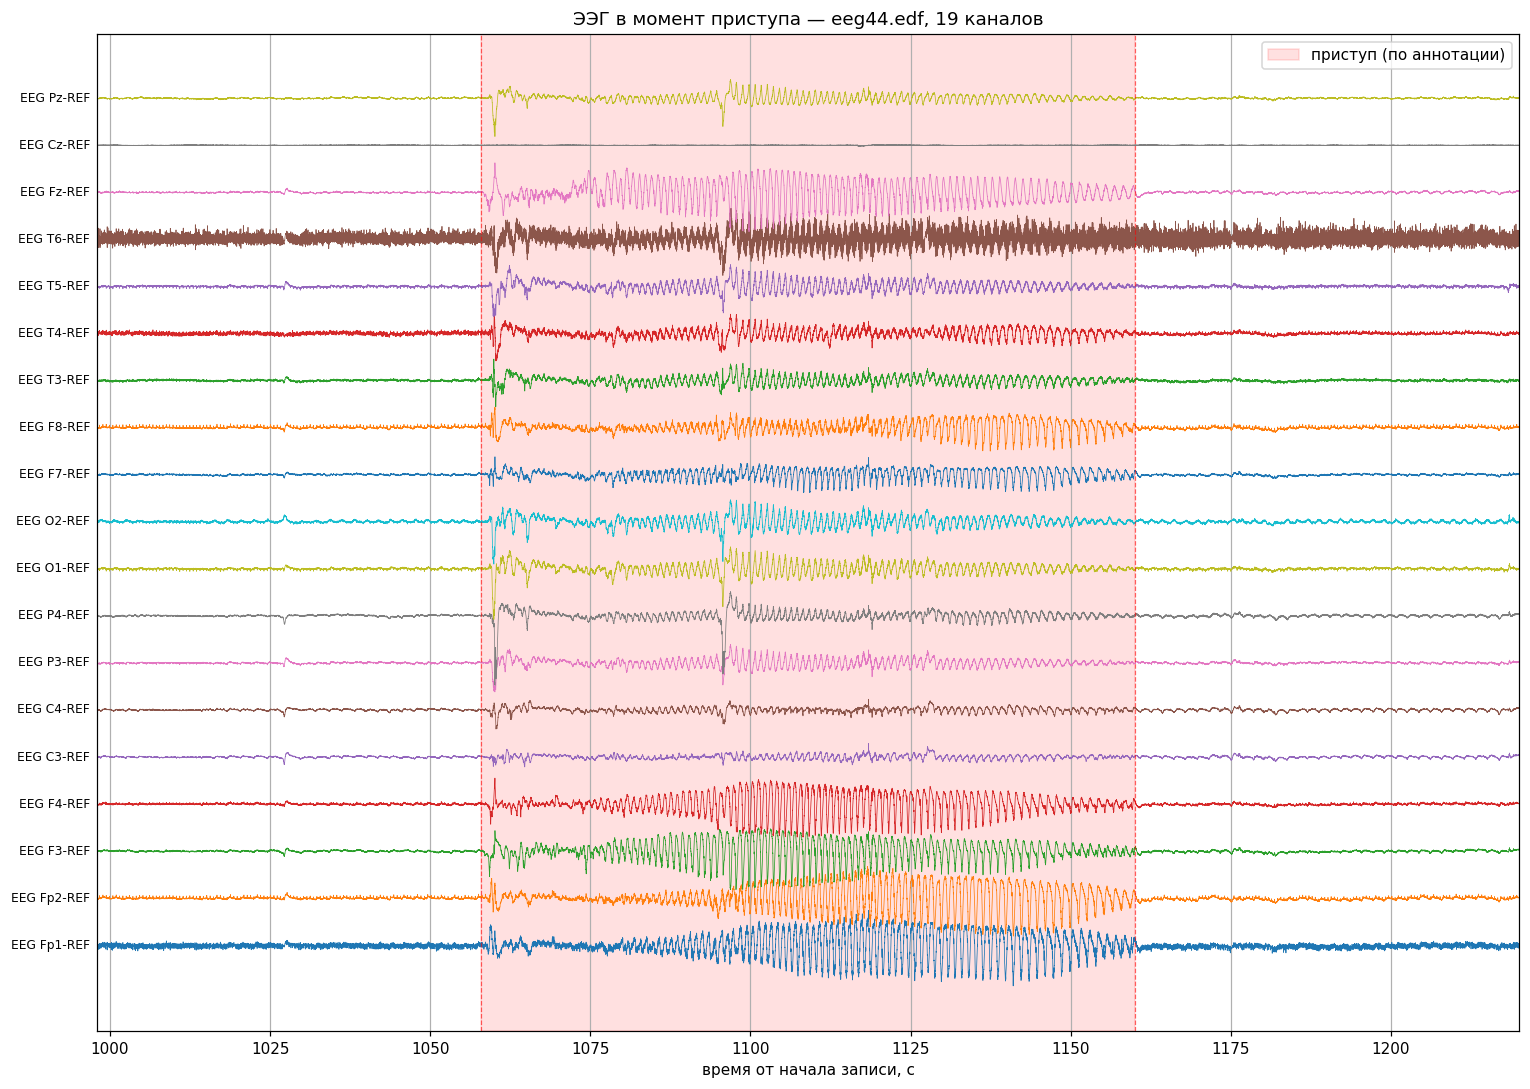

In [ ]:
offset = 150  
fig, ax = plt.subplots(figsize=(FIG_W, 10))

for k, name in enumerate(eeg_names):
    ax.plot(t, data_uv[k] + k*offset, linewidth=0.5)
    ax.text(t[0]-(t[-1]-t[0])*0.005, k*offset, name,
            va="center", ha="right", fontsize=8)

if s_sec is not None:
    ax.axvspan(s_sec, e_sec, color="red", alpha=0.12, label="приступ (по аннотации)")
    ax.axvline(s_sec, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.axvline(e_sec, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.legend(loc="upper right")

ax.set_yticks([])
ax.set_xlabel("время от начала записи, с")
ax.set_title(f"ЭЭГ в момент приступа — eeg{EEG_ID}.edf, {len(eeg_names)} каналов")
ax.margins(x=0)
plt.tight_layout()
plt.show()



## 7. Усредняем каналы в один




форма усреднённого сигнала: (56832,)
размах: -49.8 … 45.8 мкВ


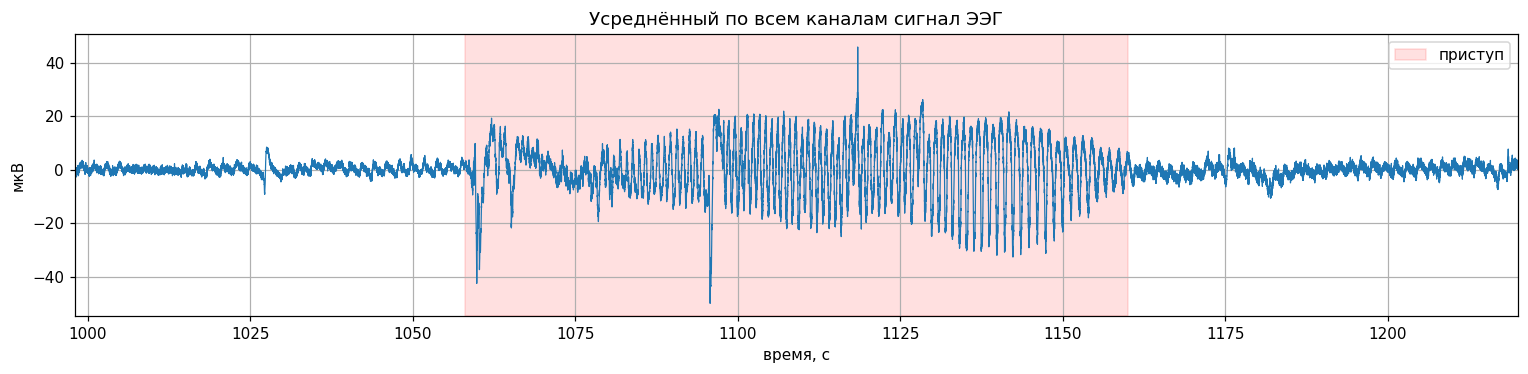

In [ ]:
mean_signal = data_uv.mean(axis=0)  
print("форма усреднённого сигнала:", mean_signal.shape)
print(f"размах: {mean_signal.min():.1f} … {mean_signal.max():.1f} мкВ")

fig, ax = plt.subplots(figsize=(FIG_W, 3.5))
ax.plot(t, mean_signal, linewidth=0.8)
if s_sec is not None:
    ax.axvspan(s_sec, e_sec, color="red", alpha=0.12, label="приступ")
    ax.legend()
ax.set_xlabel("время, с"); ax.set_ylabel("мкВ")
ax.set_title("Усреднённый по всем каналам сигнал ЭЭГ")
ax.margins(x=0)
plt.tight_layout()
plt.show()



## 8. Удаляем частоты выше 60 Гц


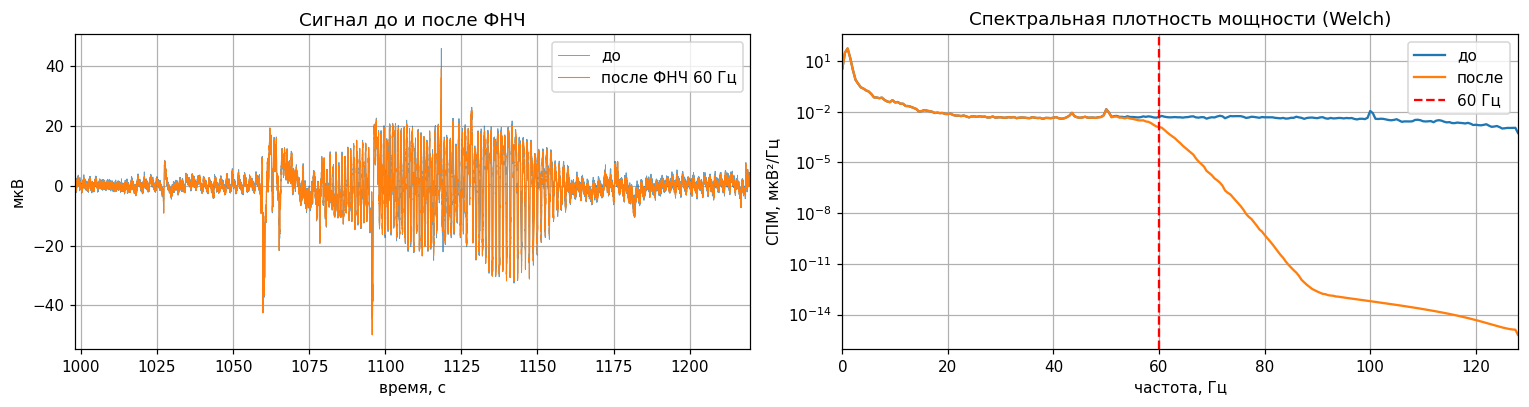

после фильтра энергия выше 60 Гц подавлена; ниже всё сохранено.


In [ ]:
CUTOFF = 60.0  
sos = sg.butter(N=8, Wn=CUTOFF, btype="lowpass", fs=fs, output="sos")
filtered = sg.sosfiltfilt(sos, mean_signal)

def psd_welch(x, fs):
    f, p = sg.welch(x, fs=fs, nperseg=int(2*fs))
    return f, p

f_b, p_b = psd_welch(mean_signal, fs)
f_a, p_a = psd_welch(filtered,    fs)

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 3.8))
axes[0].plot(t, mean_signal, label="до",  linewidth=0.6, alpha=0.7)
axes[0].plot(t, filtered,    label="после ФНЧ 60 Гц", linewidth=0.7)
axes[0].set_xlabel("время, с"); axes[0].set_ylabel("мкВ")
axes[0].set_title("Сигнал до и после ФНЧ"); axes[0].legend(); axes[0].margins(x=0)

axes[1].semilogy(f_b, p_b, label="до")
axes[1].semilogy(f_a, p_a, label="после")
axes[1].axvline(CUTOFF, color="red", linestyle="--", label="60 Гц")
axes[1].set_xlim(0, fs/2)
axes[1].set_xlabel("частота, Гц"); axes[1].set_ylabel("СПМ, мкВ²/Гц")
axes[1].set_title("Спектральная плотность мощности (Welch)")
axes[1].legend()
plt.tight_layout()
plt.show()

print("после фильтра энергия выше 60 Гц подавлена; ниже всё сохранено.")



## 9. Спектрограмма



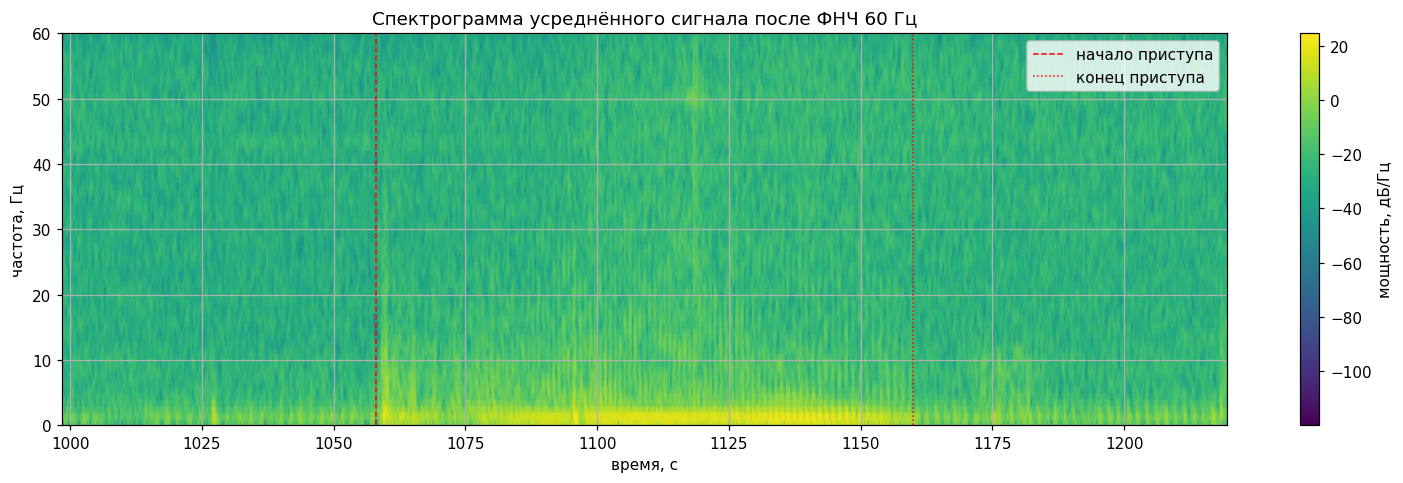

In [ ]:
nperseg  = int(fs)           
noverlap = int(0.75 * nperseg) 

f_spec, t_spec, Sxx = sg.spectrogram(
    filtered, fs=fs,
    nperseg=nperseg, noverlap=noverlap,
    window="hann", scaling="density"
)

t_spec_abs = t_spec + t_start

fig, ax = plt.subplots(figsize=(FIG_W, 4.5))
pcm = ax.pcolormesh(
    t_spec_abs, f_spec, 10*np.log10(Sxx + 1e-12),
    shading="gouraud", cmap="viridis"
)
ax.set_ylim(0, CUTOFF)         
ax.set_xlabel("время, с"); ax.set_ylabel("частота, Гц")
ax.set_title("Спектрограмма усреднённого сигнала после ФНЧ 60 Гц")
if s_sec is not None:
    ax.axvline(s_sec, color="red", linestyle="--", linewidth=1, label="начало приступа")
    ax.axvline(e_sec, color="red", linestyle=":",  linewidth=1, label="конец приступа")
    ax.legend(loc="upper right")
plt.colorbar(pcm, ax=ax, label="мощность, дБ/Гц")
plt.tight_layout()
plt.show()



## 10. Скейлограмма — непрерывное вейвлет-преобразование




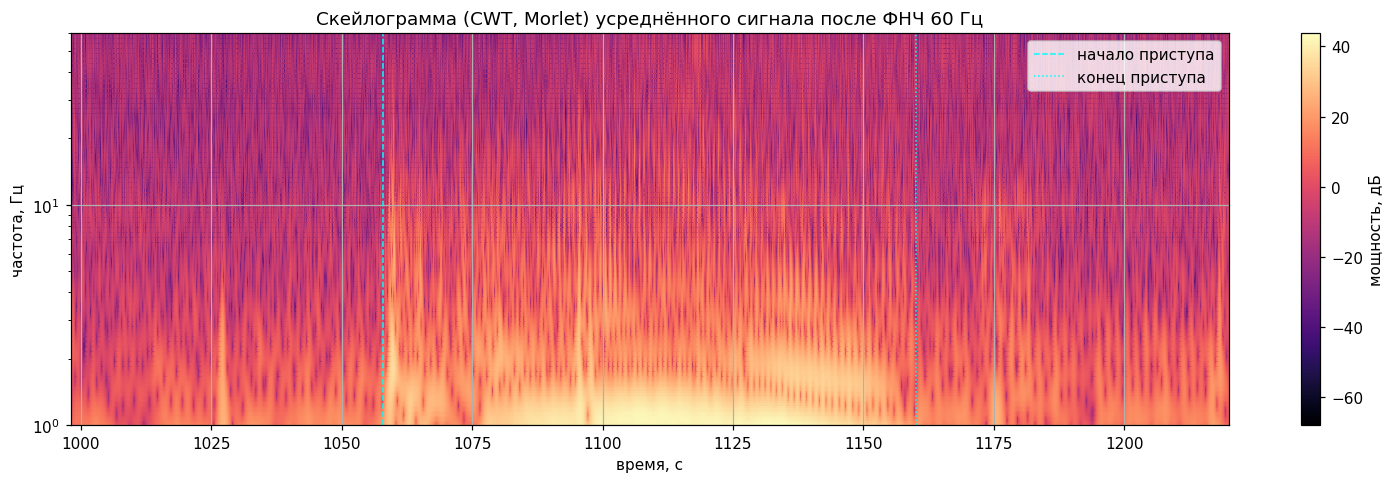

In [ ]:
wavelet = "cmor1.5-1.0"             
freqs = np.logspace(np.log10(1.0), np.log10(60.0), 80)
fc = pywt.central_frequency(wavelet)
scales = fc * fs / freqs

coefs, freqs_out = pywt.cwt(filtered, scales, wavelet, sampling_period=1.0/fs)
power = np.abs(coefs) ** 2       

fig, ax = plt.subplots(figsize=(FIG_W, 4.5))
pcm = ax.pcolormesh(
    t, freqs_out, 10*np.log10(power + 1e-12),
    shading="gouraud", cmap="magma"
)
ax.set_yscale("log")
ax.set_ylim(1, CUTOFF)
ax.set_xlabel("время, с"); ax.set_ylabel("частота, Гц")
ax.set_title("Скейлограмма (CWT, Morlet) усреднённого сигнала после ФНЧ 60 Гц")
if s_sec is not None:
    ax.axvline(s_sec, color="cyan", linestyle="--", linewidth=1, label="начало приступа")
    ax.axvline(e_sec, color="cyan", linestyle=":",  linewidth=1, label="конец приступа")
    ax.legend(loc="upper right")
plt.colorbar(pcm, ax=ax, label="мощность, дБ")
plt.tight_layout()
plt.show()



## 11. Вывод

* **На временно́м графике** в момент приступа меняется характер сигнала —
  появляются ритмичные высоко-амплитудные колебания, которых в фоне не было.
  Это «скрытая» характеристика: глазом-то она видна, но количественно описать
  её во временной области трудно.

* **Спектрограмма** показывает, как энергия по частотам перераспределяется во
  времени: во время приступа в нижних частотах (обычно 1–8 Гц для неонатального
  приступа) появляется чёткая «горячая» полоса. Это и есть скрытая
  характеристика, которой нет в самой временной развёртке.

* **Скейлограмма** даёт ту же информацию, но с переменным разрешением:
  на низких частотах граница приступа размыта по времени (зато хорошо видна
  доминирующая частота), на верхних — наоборот. Поэтому для коротких
  ЭЭГ-разрядов CWT часто информативнее STFT.

* **ФНЧ 60 Гц** убирает мышечные артефакты и часть высокочастотного шума,
  сохраняя физиологически значимый диапазон ЭЭГ (дельта/тета/альфа/бета и
  низкие гамма-ритмы).
